## Load Dataset

In [2]:
import pandas as pd
from IPython.display import display

df = pd.read_csv("./datasets/Fertilizer Datasets - datasets.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32513 entries, 0 to 32512
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     32513 non-null  float64
 1   Phosphorus   32513 non-null  float64
 2   Potassium    32513 non-null  float64
 3   Temperature  32513 non-null  float64
 4   Humidity     28000 non-null  float64
 5   Moisture     8000 non-null   float64
 6   pH_Value     24513 non-null  float64
 7   Rainfall     24513 non-null  float64
 8   Crop         32513 non-null  object 
 9   Soil_Type    32513 non-null  object 
 10  Variety      20000 non-null  object 
 11  Fertilizer   12513 non-null  object 
dtypes: float64(8), object(4)
memory usage: 3.0+ MB


In [3]:
df = df.rename(columns={"Potassium": "Kalium"})
df = df.drop(
    columns=["Humidity", "Moisture", "pH_Value", "Rainfall", "Variety", "Fertilizer"]
)

df.shape

(32513, 6)

### Style Table

In [4]:
color_variance = ["#0b559f", "#2b7bba", "#539ecd", "#89bedc", "#bad6eb", "#dbe9f6"]

df_style = {
    "border": "1px solid black",
    "border-collapse": "collapse",
    "color": "white",
    "background-color": color_variance[0],
    "font-szie": "14px",
}

table_style = [
    {
        "selector": "th",
        "props": [
            ("background-color", color_variance[0]),
            ("border", "1px solid black"),
            ("color", "white"),
        ],
    },
    {
        "selector": "th.col_heading",
        "props": [
            ("background-color", color_variance[0]),
            ("border", "1px solid black"),
            ("color", "white"),
        ],
    },
    {
        "selector": "th.row_heading",
        "props": [
            ("background-color", color_variance[0]),
            ("border", "1px solid black"),
            ("color", "white"),
        ],
    },
    {
        "selector": "tr:nth-child(even) td",
        "props": [("background-color", color_variance[2])],
    },
    {
        "selector": "tr:nth-child(odd) td",
        "props": [("background-color", color_variance[1])],
    },
    {"selector": "td", "props": [("border", "1px solid black")]},
]

## Preview

In [5]:
df.head().style.set_properties(**df_style).set_table_styles(table_style)

,Nitrogen,Phosphorus,Kalium,Temperature,Crop,Soil_Type
0,12.000000,13.000000,10.000000,26.000000,Barley,Sandy
1,21.000000,19.000000,0.000000,25.000000,Barley,Sandy
2,7.000000,30.000000,9.000000,36.000000,Barley,Sandy
3,10.000000,35.000000,0.000000,35.000000,Barley,Sandy
4,12.000000,42.000000,0.000000,30.000000,Barley,Sandy


In [6]:
num_cols = df.select_dtypes(include="number").columns.to_list()
cat_cols = df.select_dtypes(include="object").columns.to_list()

#### Check is null

In [7]:
df.isnull().sum().to_frame().T.style.set_properties(**df_style).set_table_styles(
    table_style
)

,Nitrogen,Phosphorus,Kalium,Temperature,Crop,Soil_Type
0,0,0,0,0,0,0


In [8]:
df.describe().T.style.set_properties(**df_style).set_table_styles(
    table_style
)

,count,mean,std,min,25%,50%,75%,max
Nitrogen,32513.000000,65.277172,45.465583,0.000000,22.530000,57.780000,105.990000,150.000000
Phosphorus,32513.000000,41.306131,25.058785,0.000000,20.000000,39.300000,61.240000,90.000000
Kalium,32513.000000,43.723912,33.530378,0.000000,14.000000,41.210000,69.750000,150.000000
Temperature,32513.000000,27.929758,8.576088,10.000000,21.700000,28.580000,34.360000,45.000000


In [9]:
df.describe(include="object").T.style.set_properties(**df_style).set_table_styles(
    table_style
)

,count,unique,top,freq
Crop,32513,25,Sugarcane,5057
Soil_Type,32513,13,Sandy,4892


Split "Crop" and "Soil_Type"

In [10]:
crops = df["Crop"]
soil_type = df["Soil_Type"]

crops_unique = pd.DataFrame(crops.unique()).T
soil_type_unique = pd.DataFrame(soil_type.unique()).T

print("Crop unique values:", len(crops_unique.columns))
display(crops_unique.style.set_properties(**df_style).set_table_styles(table_style))
print("Soil Type unique values:", len(soil_type_unique.columns))
display(soil_type_unique.style.set_properties(**df_style).set_table_styles(table_style))

Crop unique values: 25


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24
0,Barley,Cotton,Ginger,Gram,Grapes,Ground Nuts,Groundnut,Jowar,Maize,Masoor,Millets,Moong,Oil seeds,Paddy,Potato,Pulses,Rice,Soybean,Sugarcane,Tobacco,Tomato,Tur,Turmeric,Urad,Wheat


Soil Type unique values: 13


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,Sandy,Loamy,Clayey,Red,Black,Light Brown,Clay,Saline,Peaty,Silt,Dark Brown,Medium Brown,Reddish Brown


There is a dubplicate values "Groundnut" and "Ground Nuts", lets combine

In [11]:
df["Crop"] = df["Crop"].replace({"Groundnut": "Ground Nuts"})
crops_unique.style.set_properties(**df_style).set_table_styles(table_style)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24
0,Barley,Cotton,Ginger,Gram,Grapes,Ground Nuts,Groundnut,Jowar,Maize,Masoor,Millets,Moong,Oil seeds,Paddy,Potato,Pulses,Rice,Soybean,Sugarcane,Tobacco,Tomato,Tur,Turmeric,Urad,Wheat


### Remove minus number values

In [12]:
clean_num = df[~(df[num_cols] < 0).any(axis=1)]

In [13]:
print(df.shape)
df.head().style.set_properties(**df_style).set_table_styles(table_style)

(32513, 6)


,Nitrogen,Phosphorus,Kalium,Temperature,Crop,Soil_Type
0,12.000000,13.000000,10.000000,26.000000,Barley,Sandy
1,21.000000,19.000000,0.000000,25.000000,Barley,Sandy
2,7.000000,30.000000,9.000000,36.000000,Barley,Sandy
3,10.000000,35.000000,0.000000,35.000000,Barley,Sandy
4,12.000000,42.000000,0.000000,30.000000,Barley,Sandy


In [14]:
grouped_df = df.groupby(["Crop", "Soil_Type"], as_index=False).median(numeric_only=True)
print(grouped_df.shape)
grouped_df.head().style.set_properties(**df_style).set_table_styles(table_style)

(109, 6)


,Crop,Soil_Type,Nitrogen,Phosphorus,Kalium,Temperature
0,Barley,Black,13.000000,20.000000,2.000000,30.270000
1,Barley,Clayey,13.000000,18.500000,2.000000,29.550000
2,Barley,Loamy,14.000000,16.000000,1.000000,30.310000
3,Barley,Red,14.000000,17.000000,2.000000,30.140000
4,Barley,Sandy,15.000000,19.000000,1.000000,30.340000


### Translate and add column

In [15]:
# Dictionary translate results
crops_dict = {
    "Barley": "Jelai",
    "Cotton": "Kapas",
    "Ginger": "Jahe",
    "Gram": "Kacang Arab",
    "Grapes": "Anggur",
    "Ground Nuts": "Kacang Tanah",
    "Groundnut": "Kacang Tanah",
    "Jowar": "Sorgum",
    "Maize": "Jagung",
    "Masoor": "Kacang Merah",
    "Millets": "Beras Ketan",
    "Moong": "Kacang Hijau",
    "Oil seeds": "Biji Minyak",
    "Paddy": "Padi",
    "Potato": "Kentang",
    "Pulses": "Kacang Polong",
    "Rice": "Beras",
    "Soybean": "Kedelai",
    "Sugarcane": "Tebu",
    "Tobacco": "Tembakau",
    "Tomato": "Tomat",
    "Tur": "Kacang Toor",
    "Turmeric": "Kunyit",
    "Urad": "Kacang Hitam",
    "Wheat": "Gandum",
}

soil_type_dict = {
    "Sandy": "Berpasir",
    "Loamy": "Lempung Berpasir",
    "Clayey": "Lempung",
    "Red": "Merah",
    "Black": "Hitam",
    "Light Brown": "Cokelat Muda",
    "Clay": "Lempung",
    "Saline": "Asin",
    "Peaty": "Gambut",
    "Silt": "Endapan",
    "Dark Brown": "Cokelat Tua",
    "Medium Brown": "Cokelat Sedang",
    "Reddish Brown": "Cokelat Kemerahan",
}

In [16]:
trans_df = grouped_df.copy()

trans_df["Crop(ID)"] = trans_df["Crop"].map(crops_dict)
trans_df["Soil_Type(ID)"] = trans_df["Soil_Type"].map(soil_type_dict)

trans_df.head().style.set_properties(**df_style).set_table_styles(table_style)

,Crop,Soil_Type,Nitrogen,Phosphorus,Kalium,Temperature,Crop(ID),Soil_Type(ID)
0,Barley,Black,13.000000,20.000000,2.000000,30.270000,Jelai,Hitam
1,Barley,Clayey,13.000000,18.500000,2.000000,29.550000,Jelai,Lempung
2,Barley,Loamy,14.000000,16.000000,1.000000,30.310000,Jelai,Lempung Berpasir
3,Barley,Red,14.000000,17.000000,2.000000,30.140000,Jelai,Merah
4,Barley,Sandy,15.000000,19.000000,1.000000,30.340000,Jelai,Berpasir


In [17]:
def move_column(df: pd.DataFrame, col_to_move: str, after_col: str):
    df = df.copy()
    cols = df.columns.to_list()
    cols.remove(col_to_move)
    insert_idx = cols.index(after_col) + 1
    cols.insert(insert_idx, col_to_move)

    return cols

In [18]:
trans_df = trans_df[move_column(trans_df, "Crop(ID)", "Crop")]
trans_df = trans_df[move_column(trans_df, "Soil_Type(ID)", "Soil_Type")]

In [19]:
trans_df.head().style.set_properties(**df_style).set_table_styles(table_style)

,Crop,Crop(ID),Soil_Type,Soil_Type(ID),Nitrogen,Phosphorus,Kalium,Temperature
0,Barley,Jelai,Black,Hitam,13.000000,20.000000,2.000000,30.270000
1,Barley,Jelai,Clayey,Lempung,13.000000,18.500000,2.000000,29.550000
2,Barley,Jelai,Loamy,Lempung Berpasir,14.000000,16.000000,1.000000,30.310000
3,Barley,Jelai,Red,Merah,14.000000,17.000000,2.000000,30.140000
4,Barley,Jelai,Sandy,Berpasir,15.000000,19.000000,1.000000,30.340000


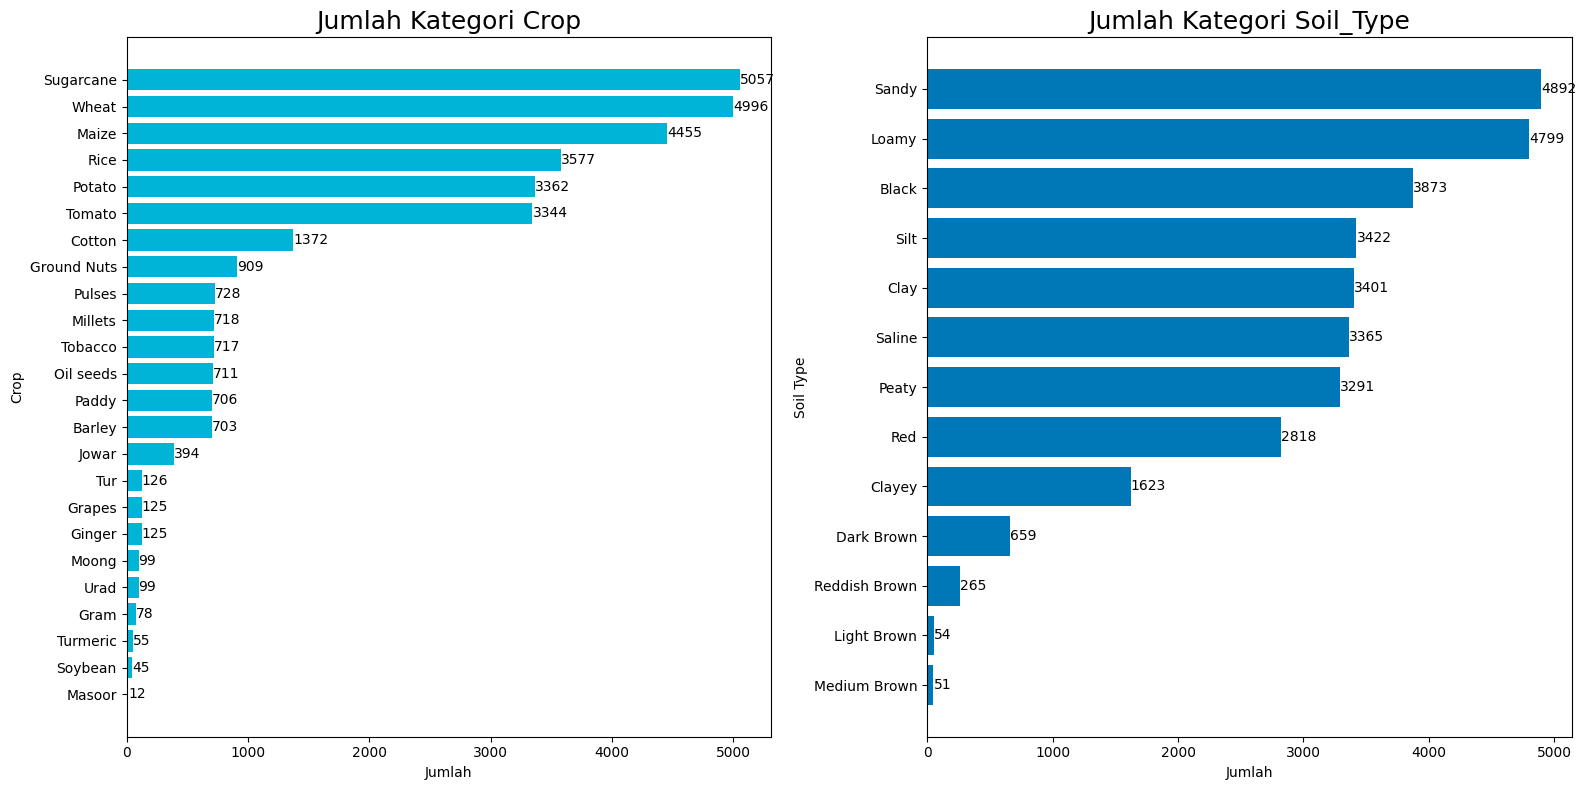

In [ ]:
import matplotlib.pyplot as plt

# Palet warna
color_variance = [
    "#0077b6",
    "#386fa4",
    "#00b4d8",
    "#118ab2",
    "#99d98c",
    "#d9ed92",
    "#ffd60a",
]

# Hitung jumlah tiap kategori
crop_counts = df["Crop"].value_counts()
soil_counts = df["Soil_Type"].value_counts()

# Buat 2 subplot berdampingan
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# --- Plot 1: Crop ---
ax[0].barh(
    crop_counts.index,
    crop_counts.values,
    color=color_variance[2],
)
ax[0].set_title("Jumlah Kategori Crop", fontsize=18)
ax[0].set_xlabel("Jumlah")
ax[0].set_ylabel("Crop")
ax[0].invert_yaxis()  # agar kategori terbesar di atas
for i, v in enumerate(crop_counts.values):
    ax[0].text(v + 0.5, i, str(v), va="center", fontsize=10)

# --- Plot 2: Soil Type ---
ax[1].barh(
    soil_counts.index,
    soil_counts.values,
    color=color_variance[0],
)
ax[1].set_title("Jumlah Kategori Soil_Type", fontsize=18)
ax[1].set_xlabel("Jumlah")
ax[1].set_ylabel("Soil Type")
ax[1].invert_yaxis()
for i, v in enumerate(soil_counts.values):
    ax[1].text(v + 0.5, i, str(v), va="center", fontsize=10)

plt.tight_layout()
plt.show()

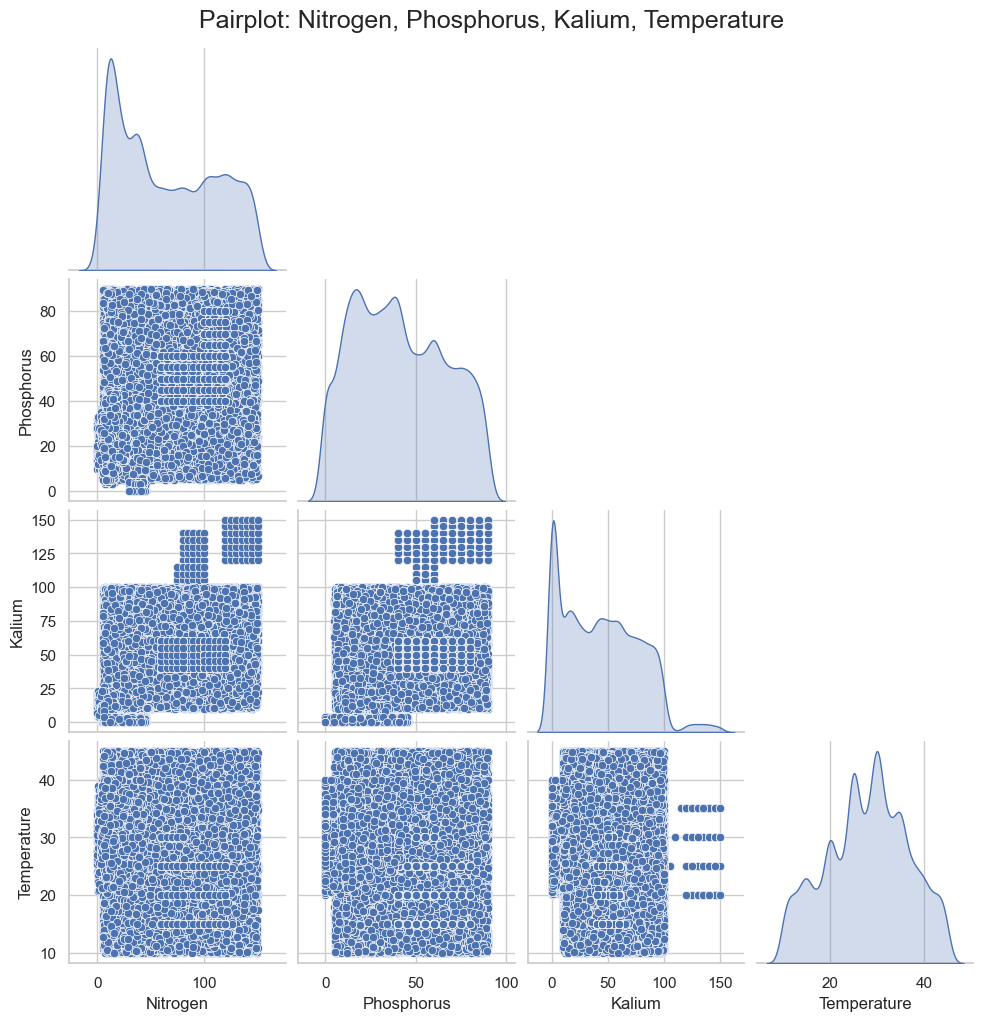

In [33]:
import seaborn as sns

cols = ["Nitrogen", "Phosphorus", "Kalium", "Temperature"]

sns.set(style="whitegrid")

# Buat pairplot
pair = sns.pairplot(
    df[cols],
    diag_kind="kde",
    corner=True, 
)

pair.fig.suptitle(
    "Pairplot: Nitrogen, Phosphorus, Kalium, Temperature", fontsize=18, y=1.02
)
plt.show()

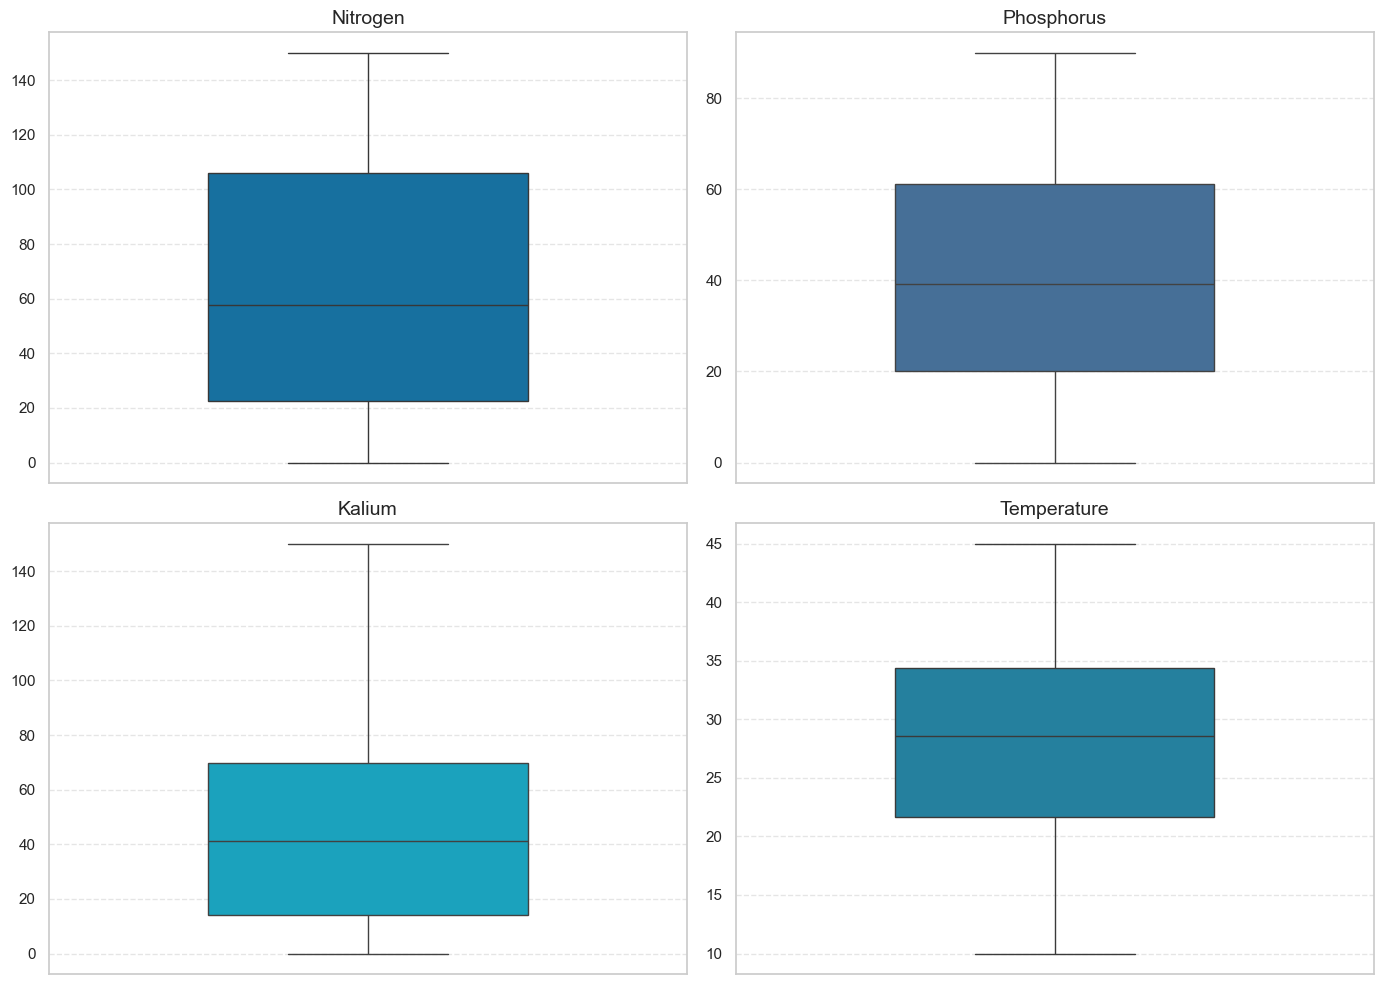

In [38]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# Flatten axes untuk memudahkan looping
axes = axes.flatten()

# Loop setiap kolom dan sumbu subplot
for i, col in enumerate(cols):
    sns.boxplot(
        y=df[col],  # batang vertikal (nilai di sumbu Y)
        ax=axes[i],
        color=color_variance[i % len(color_variance)],
        width=0.5,
    )
    axes[i].set_title(col, fontsize=14)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].grid(True, axis="y", linestyle="--", alpha=0.5)

# Rapikan tata letak
plt.tight_layout()
plt.show()

**FINAL**

In [20]:
trans_df.to_csv("./datasets/Final Fertilizer Datasets.csv")